---
# 🎯 PROJET : Prédiction du Churn Client
---
**📓 Notebook** : 01_preprocessing.ipynb   
**⚙️ Phase**    : Prétraitement & Feature Engineering   
**👤 Auteur**   : Belvin Tsadjio   
**📅 Date**     : Avril 2026   
**🔖 Version**  : 1.0   

---

## 🏢 PROBLÈME MÉTIER
Acquérir un nouveau client coûte 5 à 7x plus cher que de fidéliser un client
existant. Pour construire un modèle prédictif fiable, les données brutes
collectées doivent être nettoyées, transformées et enrichies avant tout
entraînement. Des données de mauvaise qualité produisent inévitablement
un modèle de mauvaise qualité *(Garbage In, Garbage Out)*.

---

## 🎯 OBJECTIF DE CE NOTEBOOK
Transformer les données brutes issues de la collecte en un jeu de données
propre, structuré et prêt à être consommé par les algorithmes de Machine
Learning, en préservant la cohérence entre train et test.

---

## 📋 DESCRIPTION
Ce notebook couvre l'ensemble des étapes de préparation des données
nécessaires avant la phase d'entraînement du modèle de churn.

**Les étapes réalisées dans ce notebook :**

1. 📥 Chargement des données brutes
2. 🔧 Traitement des valeurs manquantes
   - Imputation par médiane (variables numériques)
   - Vérification de la cohérence des types de données
   - Imputation par mode (variables catégorielles)
3. 🔍 Détection et traitement des outliers (IQR / Z-score)
4. 🔠 Encodage des variables catégorielles
   - One-Hot Encoding (variables nominales)
   - Label Encoding (variables ordinales)
5. 🛠️ Feature Engineering
   - Création de nouvelles variables métier
   - Agrégations comportementales (moyenne, fréquence, récence)
6. ✂️ Séparation Train / Test (stratifiée)
7. ⚖️ Normalisation / Standardisation des variables numériques
   - StandardScaler / MinMaxScaler
8. ⚖️ Traitement du déséquilibre de classes (SMOTE / undersampling)
9. 💾 Sauvegarde des données prétraitées

---

## 📤 SORTIES
   - `data/processed/train_preprocessed.csv`
   - `data/processed/test_preprocessed.csv`
   - `models/preprocessor.pkl` *(pipeline de transformation sauvegardé)*

---

## 🎯 VARIABLE CIBLE
   - **Churn** : variable binaire *(1 = client churné, 0 = client actif)*
   - 📊 Taux de churn observé dans les données brutes : **~[X]%**

---

## 📦 DÉPENDANCES
| Package | Version |
|---|---|
| scikit-learn | >= 1.3 |
| imbalanced-learn | >= 0.11 |
| pandas | >= 2.0 |
| numpy | >= 1.24 |

---

## ⚠️ NOTES IMPORTANTES
   - 🔁 Le pipeline de preprocessing est sauvegardé séparément `(preprocessor.pkl)`
     pour être réappliqué à l'identique en production sur de nouvelles données
   - 🚫 Aucune information du jeu de test ne doit *"fuiter"* dans le train *(data leakage)*
   - ✅ Le SMOTE est appliqué **UNIQUEMENT** sur le train, jamais sur le test

---

## IMPORTATION DES BIBLIOTHEQUES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import joblib



In [3]:
df=pd.read_csv("Customer_Churn_data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 📖 DICTIONNAIRE DES DONNÉES
**Dataset** : Telco Customer Churn
**Observations** : 7 043 clients
**Variables** : 21 colonnes

---

### 🪪 IDENTIFICATION
| # | Variable | Type | Description | Valeurs |
|---|---|---|---|---|
| 0 | `customerID` | object | Identifiant unique du client | Ex: 7590-VHVEG |

---

### 👤 DONNÉES DÉMOGRAPHIQUES
| # | Variable | Type | Description | Valeurs |
|---|---|---|---|---|
| 1 | `gender` | object | Genre du client | Male / Female |
| 2 | `SeniorCitizen` | int64 | Le client est-il une personne âgée ? | 0 = Non / 1 = Oui |
| 3 | `Partner` | object | Le client a-t-il un conjoint ? | Yes / No |
| 4 | `Dependents` | object | Le client a-t-il des personnes à charge ? | Yes / No |

---

### 📞 SERVICES SOUSCRITS
| # | Variable | Type | Description | Valeurs |
|---|---|---|---|---|
| 6 | `PhoneService` | object | Abonnement au service téléphonique | Yes / No |
| 7 | `MultipleLines` | object | Abonnement à plusieurs lignes téléphoniques | Yes / No / No phone service |
| 8 | `InternetService` | object | Type de connexion internet souscrite | DSL / Fiber optic / No |
| 9 | `OnlineSecurity` | object | Option sécurité en ligne activée | Yes / No / No internet service |
| 10 | `OnlineBackup` | object | Option sauvegarde en ligne activée | Yes / No / No internet service |
| 11 | `DeviceProtection` | object | Option protection des appareils activée | Yes / No / No internet service |
| 12 | `TechSupport` | object | Option support technique activé | Yes / No / No internet service |
| 13 | `StreamingTV` | object | Option streaming TV activée | Yes / No / No internet service |
| 14 | `StreamingMovies` | object | Option streaming films activée | Yes / No / No internet service |

---

### 💼 INFORMATIONS CONTRACTUELLES
| # | Variable | Type | Description | Valeurs |
|---|---|---|---|---|
| 5 | `tenure` | int64 | Ancienneté du client en mois | 0 à 72 mois |
| 15 | `Contract` | object | Type de contrat souscrit | Month-to-month / One year / Two year |
| 16 | `PaperlessBilling` | object | Facturation dématérialisée activée | Yes / No |
| 17 | `PaymentMethod` | object | Méthode de paiement utilisée | Electronic check / Mailed check / Bank transfer / Credit card |

---

### 💰 DONNÉES FINANCIÈRES
| # | Variable | Type | Description | Valeurs | ⚠️ Anomalie |
|---|---|---|---|---|---|
| 18 | `MonthlyCharges` | float64 | Montant facturé mensuellement | Ex: 29.85 € | ✅ RAS |
| 19 | `TotalCharges` | object | Montant total facturé depuis le début | Ex: 1889.5 € | ⚠️ Devrait être float64 → à convertir |

---

### 🎯 VARIABLE CIBLE
| # | Variable | Type | Description | Valeurs |
|---|---|---|---|---|
| 20 | `Churn` | object | Le client a-t-il résilié son contrat ? | Yes = Churner / No = Client actif |

---

## ⚠️ POINTS D'ATTENTION POUR LE PREPROCESSING

| Observation | Action recommandée |
|---|---|
| `customerID` est un identifiant pur | 🗑️ À supprimer avant l'entraînement |
| `TotalCharges` est de type object | 🔧 Convertir en float64 — contient probablement des espaces vides `" "` |
| `SeniorCitizen` est déjà encodé en 0/1 | ✅ Aucune transformation nécessaire |
| `Churn` est de type object (Yes/No) | 🔧 Encoder en binaire : Yes → 1 / No → 0 |
| Variables avec "No internet service" | 🔧 Regrouper avec "No" ou encoder séparément |

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Check des valeur manquantes
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Convertir TotalCharges en numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Traitement des valeurs manquantes générées par la conversion
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# On convertir Churn en valeur binaire (0,1)
df["Churn"]=df["Churn"].map({"No":0, "Yes":1})

In [10]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


 =============================================================================
# FEATURES LES PLUS IMPACTANTES
 =============================================================================

 - tenure          : Ancienneté du client en mois
                     (plus le client est ancien, plus le risque de churn est faible)

 - Contract        : Type de contrat souscrit
                     (les clients avec un contrat mensuel ont un risque de churn plus élevé
                     que ceux avec un contrat annuel ou bi-annuel)

 - MonthlyCharges  : Montant facturé mensuellement
                     (des charges élevées sont corrélées à un risque de churn plus fort)

 - TotalCharges    : Montant total dépensé depuis le début de l'utilisation du service
                     (fortement corrélé à tenure — attention à la multicolinéarité)

 - SeniorCitizen   : Indique si le client est une personne âgée (1 = Oui, 0 = Non)
                     (les seniors présentent un taux de churn plus élevé)

 - Partner         : Indique si le client a un conjoint (Yes / No)
                     (les clients sans conjoint sont plus enclins à résilier)

 - Dependents      : Indique si le client a des personnes à charge (Yes / No)
                     (les clients sans dépendants ont un risque de churn plus élevé)

 =============================================================================

In [11]:
df[df["MonthlyCharges"]== 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


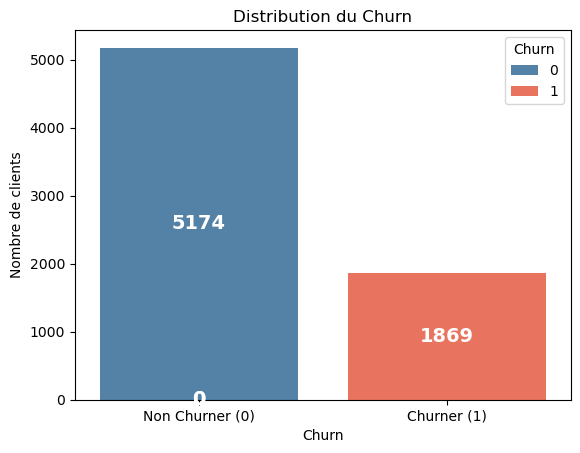

In [13]:
# Distribution du Churn

df["Churn"].value_counts()
ax = sns.countplot(x="Churn", data=df, palette=["steelblue", "tomato"],hue="Churn")

# Afficher le nombre à l'intérieur de chaque barre
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # centre horizontal
        bar.get_height() / 2,               # centre vertical de la barre
        str(int(bar.get_height())),          # valeur
        ha="center", va="center",
        fontsize=14, fontweight="bold", color="white"
    )

plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.title("Distribution du Churn")
plt.xticks([0, 1], ["Non Churner (0)", "Churner (1)"])
plt.show()


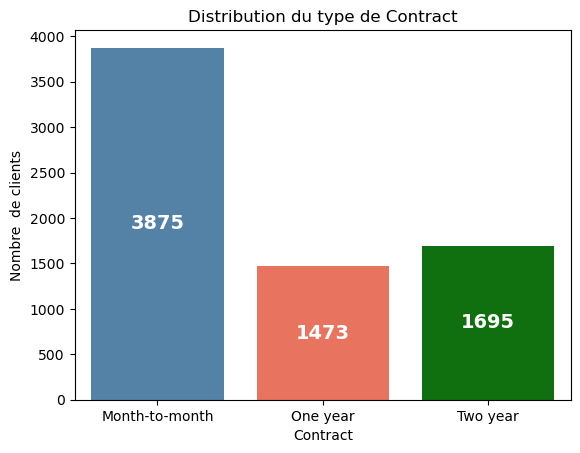

In [14]:
# Distribution du contrat
ax=sns.countplot(x="Contract",data=df,palette=["steelblue","tomato","green"], hue="Contract")

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        str(int(bar.get_height())),
        ha="center",va="center",
        fontsize=14,fontweight="bold",color="white"
    )

plt.title("Distribution du type de Contract")
plt.xlabel("Contract")
plt.ylabel("Nombre  de clients")
plt.show()

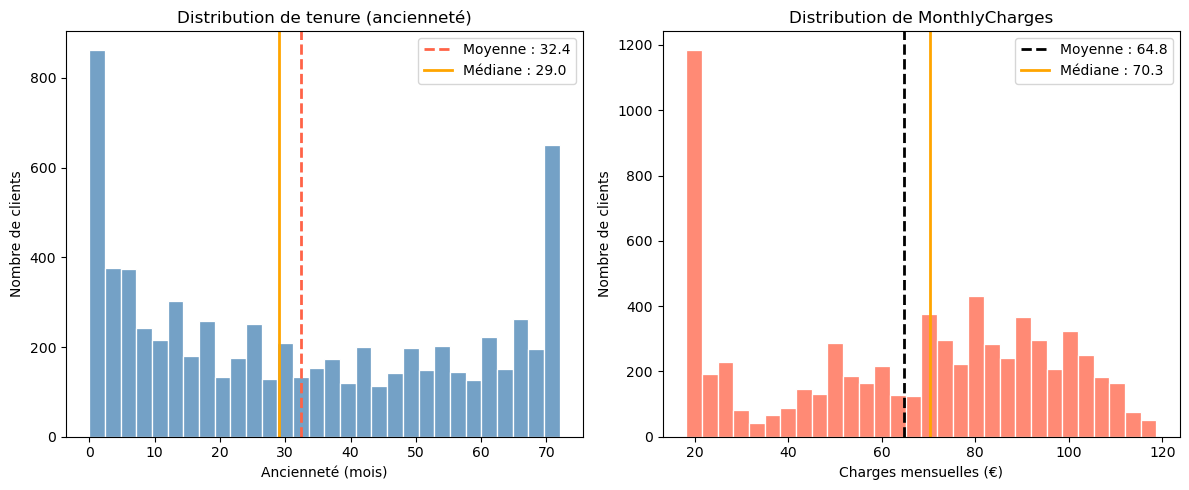

In [15]:
# Distribution de la variable tenure et MonthlyCharges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Graphique 1 : tenure ──────────────────────────────────────
sns.histplot(df["tenure"], bins=30, ax=axes[0], color="steelblue", edgecolor="white")

moyenne_tenure = df["tenure"].mean()
mediane_tenure = df["tenure"].median()

axes[0].axvline(moyenne_tenure, color="tomato", linestyle="--", linewidth=2, label=f"Moyenne : {moyenne_tenure:.1f}")
axes[0].axvline(mediane_tenure, color="orange", linestyle="-",  linewidth=2, label=f"Médiane : {mediane_tenure:.1f}")

axes[0].set_title("Distribution de tenure (ancienneté)")
axes[0].set_xlabel("Ancienneté (mois)")
axes[0].set_ylabel("Nombre de clients")
axes[0].legend()

# ── Graphique 2 : MonthlyCharges ─────────────────────────────
sns.histplot(df["MonthlyCharges"], bins=30, ax=axes[1], color="tomato", edgecolor="white")

moyenne_mc = df["MonthlyCharges"].mean()
mediane_mc = df["MonthlyCharges"].median()

axes[1].axvline(moyenne_mc, color="black",  linestyle="--", linewidth=2, label=f"Moyenne : {moyenne_mc:.1f}")
axes[1].axvline(mediane_mc, color="orange", linestyle="-",  linewidth=2, label=f"Médiane : {mediane_mc:.1f}")

axes[1].set_title("Distribution de MonthlyCharges")
axes[1].set_xlabel("Charges mensuelles (€)")
axes[1].set_ylabel("Nombre de clients")
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [17]:
df["TechSupport"]=df["TechSupport"].replace("No internet service","No")

In [18]:
df["TechSupport"].value_counts()

TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

In [19]:
df[["Partner","Dependents"]].value_counts()

Partner  Dependents
No       No            3280
Yes      Yes           1749
         No            1653
No       Yes            361
Name: count, dtype: int64

# **Heatmap** pour voir les correlation entre variable

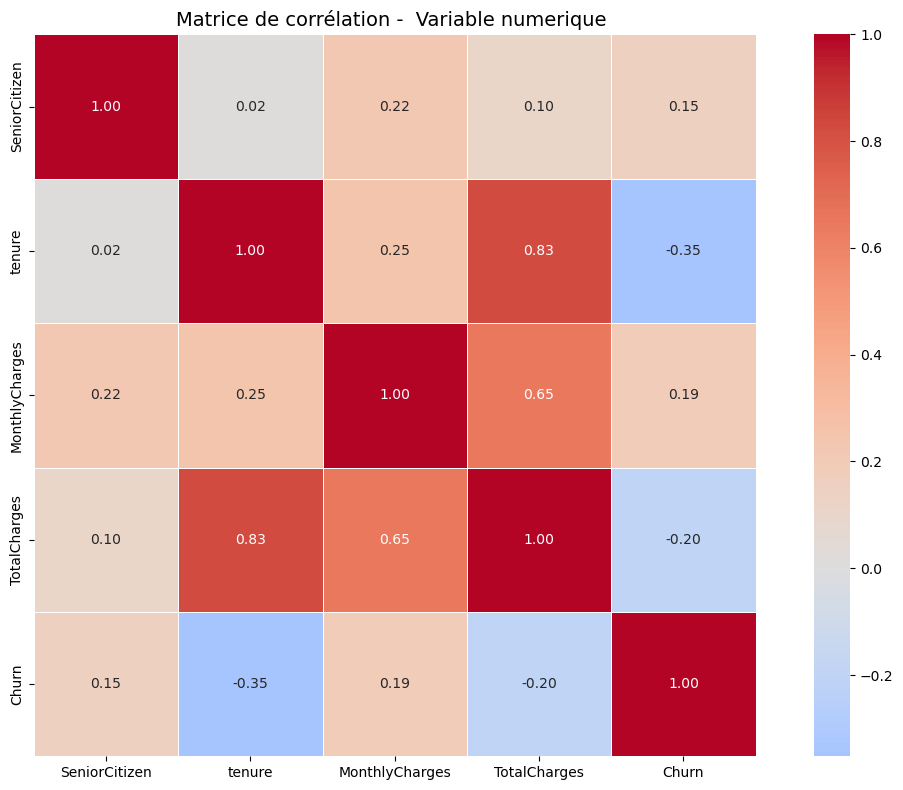

In [20]:
numerical_feat=df.select_dtypes(include='number')
numerical_feat
# matriice de correlation
matrice_corr=numerical_feat.corr()
# visualisation

plt.figure(figsize=(12,8))
sns.heatmap(matrice_corr,
            annot=True,  # Affiche les valeurs

            fmt='.2f',  # 2 décimales
            cmap='coolwarm',  # Rouge = corrélation positive, Bleu = négative
            center=0,         # Centre la colormap sur 0
            square=True,    # Cellules carrées
            linewidths=0.5)   # Séparation entre cellules
plt.title('Matrice de corrélation -  Variable numerique ', fontsize=14)
plt.tight_layout()


# Detection et traitement des Outliers
Nous allons utilisé la methode de l'écart interquartile(IQR) qui mesure la dispersion des données au centre d'un jeu de données
    **IQR=Q3-Q1**

Series([], Name: tenure, dtype: int64)


<Axes: ylabel='tenure'>

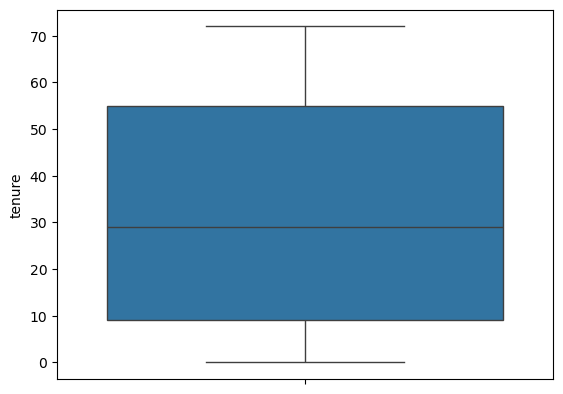

In [21]:
# Variable tenure
Q1=df['tenure'].quantile(0.25)
Q3=df['tenure'].quantile(0.75)
IQR=Q3-Q1
outliers=df['tenure'][(df['tenure']<Q1-1.5*IQR) | (df['tenure']>Q3+1.5*IQR)]
print(outliers)  
# resultat : Series([], Name: tenure, dtype: int64) c'est qui signifie qu'il y'a ps outliers
# confirmons en tracans le boxplot
sns.boxplot(data=df,y='tenure')

MonthlyCharges outliers: Series([], Name: MonthlyCharges, dtype: float64)
TotalCharges outliers: Series([], Name: TotalCharges, dtype: float64)


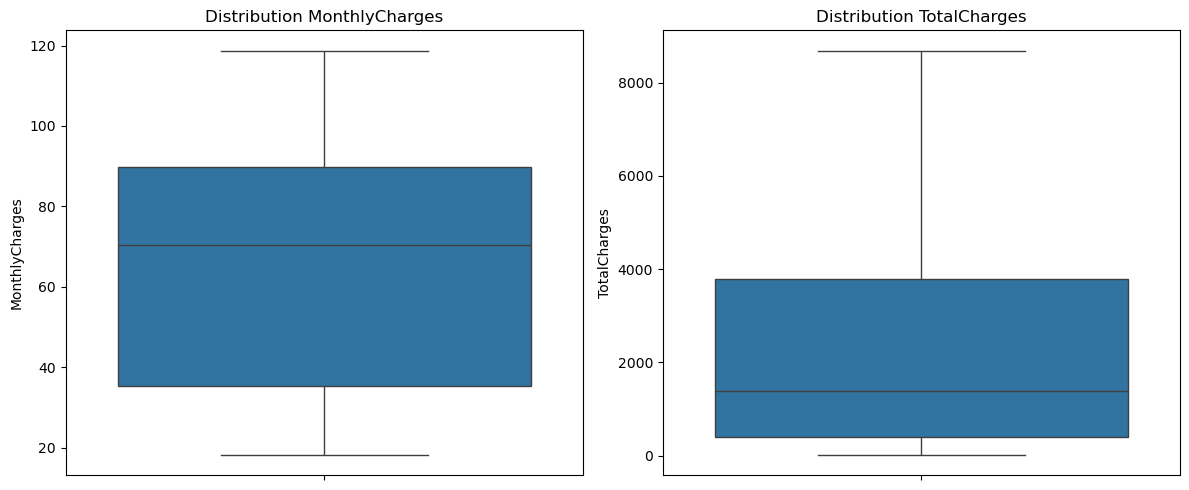

In [22]:
# variable MonthlyCharges et TotalCharges
Q1m=df['MonthlyCharges'].quantile(0.25)
Q3m=df['MonthlyCharges'].quantile(0.75)
IQRm=Q3m-Q1m
outlier_m=df['MonthlyCharges'][(df['MonthlyCharges']<Q1m-1.5*IQRm) | (df['MonthlyCharges']>Q3m+1.5*IQRm)]
print('MonthlyCharges outliers:', outlier_m)

# variable TotalCharges
Q1t=df['TotalCharges'].quantile(0.25)
Q3t=df['TotalCharges'].quantile(0.75)
IQRt=Q3t-Q1t
outlier_t=df['TotalCharges'][(df['TotalCharges']<Q1t-1.5*IQRt) | (df['TotalCharges']>Q3t+1.5*IQRt)]
print('TotalCharges outliers:', outlier_t)

# Boxplot pour les deux variables
fig, axes=plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=df, y='MonthlyCharges', ax=axes[0])
axes[0].set_title('Distribution MonthlyCharges')
sns.boxplot(data=df, y='TotalCharges', ax=axes[1])
axes[1].set_title('Distribution TotalCharges')
plt.tight_layout()
plt.show()

# 🔧 Feature Engineering

> Cette étape consiste à enrichir le dataset en **créant de nouvelles variables métier** à partir des données brutes existantes, afin d'améliorer la capacité prédictive du modèle final.

---

## 📊 Agrégations Comportementales

Les agrégations comportementales permettent de **résumer le comportement historique** de chaque entité (client, utilisateur, etc.) en variables synthétiques exploitables par le modèle.

Plutôt que de travailler sur des événements bruts (lignes de transactions, clics, actions...), on construit **une ligne par entité** contenant des indicateurs statistiques qui encodent son profil comportemental.

Les deux familles principales utilisées ici sont :

- **La moyenne** — capture le comportement typique d'une entité (montant moyen d'achat, score moyen, délai moyen entre deux événements). Elle lisse les variations ponctuelles et donne une image représentative du profil.

- **La fréquence** — capture le rythme d'activité d'une entité (nombre de transactions, nombre de connexions, nombre d'interactions sur une période). Elle reflète l'intensité du comportement.

Ces agrégations sont calculées sur des **fenêtres temporelles définies** (7j, 30j, 90j) afin de capturer à la fois le comportement récent et le profil long terme.

1. Comptage du nombre de service par clients

In [23]:
# Nous appliquons l'agregation comportementale pour compter le nombre de service par client car plus c'est grand c'est moin probable que le client churn
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies']
# On cree un nouveau feature NbServices

df['NbServices'] = df[services].apply(lambda row: (row == 'Yes').sum(), axis=1)

2. Segmentation des client par ancienneté

In [24]:
df['TenureSegment']=pd.cut(df['tenure'], bins=[0,12,24,48,72],labels=['Nouveau', 'Junior', 'Etabli', 'Fidèle'],include_lowest=True )

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NbServices,TenureSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Nouveau
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,3,Etabli
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3,Nouveau
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,Etabli
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,Nouveau


 # Encodage des valeurs categorielle et valeurs binaire

In [26]:
binary_feature=["Partner","Dependents","TechSupport"]
for col in binary_feature:
    df[col]=df[col].map({"No":0,"Yes":1})

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   int64   
 4   Dependents        7043 non-null   int64   
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   int64   
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [28]:
# ============================================================
# Encodage des variables catégorielles
# ============================================================

df_encoder = df.copy()

# --- Méthode 1 : pandas get_dummies (simple) ---
df_encoding = df.copy()
df_encoding = pd.get_dummies(df_encoding, columns=["Contract"], drop_first=True, dtype=int)

# --- Méthode 2 : scikit-learn OneHotEncoder (scalable) ---
ct = ColumnTransformer(
    transformers=[
        ('one', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Contract'])
    ],
    remainder='passthrough'
).set_output(transform='pandas')   # retourne directement un DataFrame propre

df_result = ct.fit_transform(df_encoder)

# Nettoyage des préfixes (one__ et remainder__)
df_result.columns = [col.replace('one__', '').replace('remainder__', '')
                     for col in df_result.columns]


# ============================================================
# Encodage de la variable tenureSegment
# ============================================================

# On utilise cette approche parce que TenureSegment est une variable ordinale
order_encod=OrdinalEncoder(categories=[['Nouveau', 'Junior', 'Etabli', 'Fidèle']])
df_result['TenureSegment_enc']=order_encod.fit_transform(df_result[['TenureSegment']])


In [29]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Contract_One year  7043 non-null   float64 
 1   Contract_Two year  7043 non-null   float64 
 2   customerID         7043 non-null   object  
 3   gender             7043 non-null   object  
 4   SeniorCitizen      7043 non-null   int64   
 5   Partner            7043 non-null   int64   
 6   Dependents         7043 non-null   int64   
 7   tenure             7043 non-null   int64   
 8   PhoneService       7043 non-null   object  
 9   MultipleLines      7043 non-null   object  
 10  InternetService    7043 non-null   object  
 11  OnlineSecurity     7043 non-null   object  
 12  OnlineBackup       7043 non-null   object  
 13  DeviceProtection   7043 non-null   object  
 14  TechSupport        7043 non-null   int64   
 15  StreamingTV        7043 non-null   object  
 16  Stream

In [30]:
df_result[["Contract_One year","Contract_Two year"]]=df_result[["Contract_One year","Contract_Two year"]].astype(int)


In [31]:
df_result.head()

,Contract_One year,Contract_Two year,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,...,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NbServices,TenureSegment,TenureSegment_enc
0,0,0,7590-VHVEG,Female,0,1,0,1,No,No phone service,...,No,No,Yes,Electronic check,29.85,29.85,0,1,Nouveau,0.0
1,1,0,5575-GNVDE,Male,0,0,0,34,Yes,No,...,No,No,No,Mailed check,56.95,1889.50,0,3,Etabli,2.0
2,0,0,3668-QPYBK,Male,0,0,0,2,Yes,No,...,No,No,Yes,Mailed check,53.85,108.15,1,3,Nouveau,0.0
3,1,0,7795-CFOCW,Male,0,0,0,45,No,No phone service,...,No,No,No,Bank transfer (automatic),42.30,1840.75,0,3,Etabli,2.0
4,0,0,9237-HQITU,Female,0,0,0,2,Yes,No,...,No,No,Yes,Electronic check,70.70,151.65,1,1,Nouveau,0.0


In [32]:
num=df_result.select_dtypes(include='number')
num.columns

Index(['Contract_One year', 'Contract_Two year', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'TechSupport', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'NbServices', 'TenureSegment_enc'],
      dtype='object')

# Normalisation & Standardisation

> Cette étape sert à mettre toutes les variables numériques sur la même échelle pour que le
> modèle ne soit pas biaisé par les unités ou l'amplitude des valeurs.

Pour ce cas, j'ai opté pour la **standardisation** plutôt que la normalisation pour les raisons suivantes :

- **Convergence du gradient descent** : la standardisation accélère la convergence en maintenant
les features sur une échelle comparable, évitant que le gradient oscille.

- **Équilibre des features** : elle supprime le biais d'échelle entre les variables (ex: `tenure`
en dizaines vs `TotalCharges` en milliers) sans écraser les distributions.

- **Robustesse** : contrairement à la normalisation (Min-Max), elle est moins sensible aux valeurs
extrêmes car elle repose sur la moyenne et l'écart-type, pas sur les bornes.

- **Convention pour les modèles linéaires** : la régression logistique suppose implicitement des
features centrées et réduites — la standardisation respecte cette hypothèse, même en l'absence
d'outliers significatifs.

> La normalisation (Min-Max) aurait été préférable uniquement si les features avaient des
> distributions bornées connues ou pour des algorithmes sensibles aux distances comme le KNN.

In [33]:
# ⚠️ La normalisation est appliquée APRÈS le split et le SMOTE
# pour éviter le data leakage (cf. section ci-dessous)

* Les valeurs **négatives** → en dessous de la moyenne
* Les valeurs **positives** → au dessus de la moyenne
* Les valeurs proches de **0** → proches de la moyenne

# ⚖️ Traitement du Déséquilibre de Classes

L'analyse de la distribution de la variable cible `Churn` révèle un déséquilibre notable :
- **70%** des clients ne churne pas → classe majoritaire
- **30%** des clients churne → classe minoritaire

Ce déséquilibre, bien que modéré, est suffisant pour biaiser le modèle vers la classe majoritaire.
Un classifieur naïf pourrait atteindre 70% d'accuracy en prédisant systématiquement "Non Churn",
sans jamais détecter un seul client à risque — ce qui le rendrait inutile en production.

Il est donc nécessaire de **rééquilibrer les classes** avant l'entraînement du modèle
afin de garantir une détection fiable des clients churners.

Dans ce contexte — dataset de taille modeste (~7 000 lignes) et déséquilibre modéré —
nous optons pour la méthode **SMOTE** (Synthetic Minority Oversampling Technique).
Cette approche génère des exemples synthétiques de la classe minoritaire sans supprimer
d'information existante, ce qui la rend préférable à l'undersampling sur un dataset de cette taille.

In [34]:
# ── Définition de X et y ──────────────────────────────────────────
y = df_result['Churn']
X = df_result.drop(columns=['Churn', 'customerID'])

# Encodage One-Hot des variables catégorielles restantes
cols_ohe = ['gender', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
X = pd.get_dummies(X, columns=cols_ohe, drop_first=True)
X = X.drop(columns=['TenureSegment'])

# ── Split Train / Test (stratifié) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Normalisation — fit sur train uniquement (évite le data leakage) ──
standard_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[standard_cols] = scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols]  = scaler.transform(X_test[standard_cols])  # transform seulement

# ── SMOTE — appliqué uniquement sur le train ───────────────────────
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Distribution après SMOTE:')
print(y_train_res.value_counts())
print(f'Shape X_train_res: {X_train_res.shape}')

Distribution après SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64
Shape X_train_res: (8278, 31)


In [35]:
df_result['Churn'].value_counts(normalize=True)*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Contract_One year                      7043 non-null   int64  
 1   Contract_Two year                      7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   TechSupport                            7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   NbServices                             7043 non-null   int64  
 10  TenureSegment_enc                      7043 non-null   float64
 11  gend

In [37]:
X_train_res.shape

(8278, 31)

In [38]:
X_train_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8278 entries, 0 to 8277
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Contract_One year                      8278 non-null   int64  
 1   Contract_Two year                      8278 non-null   int64  
 2   SeniorCitizen                          8278 non-null   int64  
 3   Partner                                8278 non-null   int64  
 4   Dependents                             8278 non-null   int64  
 5   tenure                                 8278 non-null   float64
 6   TechSupport                            8278 non-null   int64  
 7   MonthlyCharges                         8278 non-null   float64
 8   TotalCharges                           8278 non-null   float64
 9   NbServices                             8278 non-null   int64  
 10  TenureSegment_enc                      8278 non-null   float64
 11  gend

# Sauvegarde des données prétraité

In [39]:
joblib.dump(X_train_res, 'X_train.pkl')
joblib.dump(X_test,      'X_test.pkl')
joblib.dump(y_train_res, 'y_train.pkl')  # ← y minuscule comme X_test
joblib.dump(y_test,      'y_test.pkl')

['y_test.pkl']

In [41]:
import joblib, json

# Artefacts manquants — à sauvegarder maintenant
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(order_encod,   'ordinal_encoder.pkl')

# Noms exacts des 31 colonnes dans le bon ordre
json.dump(list(X_train_res.columns), open('feature_names.json', 'w'))